In [1]:
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:

data={
    'job_skills': ['Python', 'SQL', 'Excel', 'Power BI', 'Tableau', 'R', 'SAS', 'Java', 'C++', 'JavaScript'],
    'skill_count': [150, 120, 100, 80, 60, 50, 40, 30, 20, 10],
    'skill_pay': [120000, 110000, 90000, 95000, 100000, 85000, 80000, 75000, 70000, 65000]
}
ds= pd.DataFrame(data)

<Axes: xlabel='skill_count', ylabel='skill_pay'>

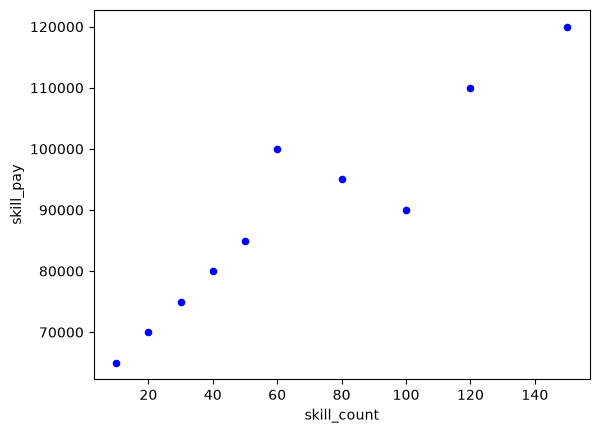

In [3]:
ds.plot(kind='scatter', x='skill_count', y='skill_pay', color='blue')

In [4]:
print(df)

             job_title_short  \
0       Senior Data Engineer   
1               Data Analyst   
2              Data Engineer   
3              Data Engineer   
4              Data Engineer   
...                      ...   
785736     Software Engineer   
785737          Data Analyst   
785738      Business Analyst   
785739         Data Engineer   
785740     Software Engineer   

                                                job_title  \
0       Senior Clinical Data Engineer / Principal Clin...   
1                                            Data Analyst   
2       Data Engineer/Scientist/Analyst, Mid or Senior...   
3       LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...   
4                                  Data Engineer- Sr Jobs   
...                                                   ...   
785736                                    DevOps Engineer   
785737                                   CRM Data Analyst   
785738                     Commercial Analyst - Start Now   
78573

In [5]:
df=df[df['job_title_short']=='Data Scientist']

In [6]:
df_exploded= df.explode('job_skills')

In [11]:
skill_stats= df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

In [15]:
skill_stats= skill_stats.sort_values(by='skill_count', ascending=False).head(10)

NameError: name 'fig' is not defined

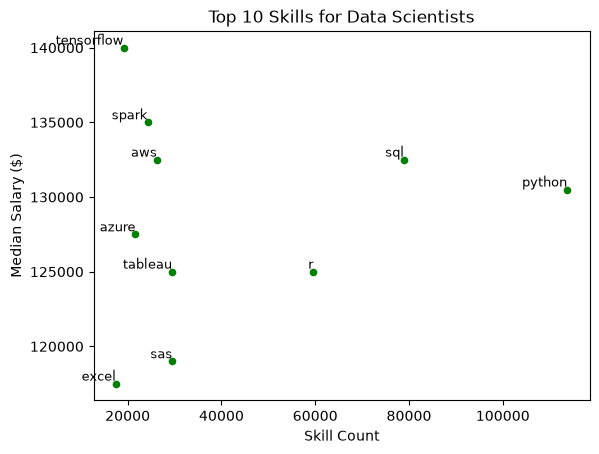

In [ ]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary', color='green')
plt.title('Top 10 Skills for Data Scientists')
plt.xlabel('Skill Count')   
plt.ylabel('Median Salary ($)')

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt, fontsize=9, ha='right', va='bottom')

